# 11. Resource Attribution & Contribution Ablation Study (E0 - E8)
Aggregates saved per-experiment results (from notebook 09 / `scripts/run_ablation.sh`) into the attribution matrix and resource-contribution waterfall. **Uses illustrative synthetic numbers below where no real results exist yet** -- swap in `AblationAggregator.load_all_results()` once experiments have run.

In [ ]:
# ============================================================
# PATH & REPO AUTO-SYNC BOOSTER — Guarantees latest project code
# ============================================================
import os, sys, site, urllib.request, zipfile

# Purge cached 'src' modules from memory so updated files take effect immediately
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

user_site = site.getusersitepackages()
if user_site not in sys.path:
    sys.path.insert(0, user_site)

try:
    cwd = os.getcwd()
except FileNotFoundError:
    cwd = os.path.expanduser('~')
    os.chdir(cwd)

home     = os.path.expanduser('~')
proj_dir = os.path.join(home, 'Ekegusii-LLM-Translation-main')

# ALWAYS auto-sync latest code from GitHub
try:
    print('🔄 Syncing latest code from GitHub main branch...')
    zip_path = os.path.join(home, 'repo.zip')
    urllib.request.urlretrieve('https://github.com/aykahsay/Ekegusii-LLM-Translation/archive/refs/heads/main.zip', zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(home)
    os.remove(zip_path)
    print('✅ Repository auto-synced to latest GitHub commit!')
except Exception as exc:
    print(f'⚠️ Auto-sync notice: {exc} (using local code)')

if os.path.isdir(proj_dir):
    os.chdir(proj_dir)
elif os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

# Purge cached 'src' modules again after chdir
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

print(f'Working Directory : {os.getcwd()}')
print(f'Python Kernel     : {sys.executable}')


In [2]:
# ============================================================
# ABI CHECK -- numpy/pandas binary compatibility.
# Some Jupyter hosts (e.g. Kineses Cloud conda envs) ship a numpy/pandas
# pair whose compiled C-extension ABI doesn't match, raising
# "numpy.dtype size changed, may indicate binary incompatibility" the
# moment pandas -- and therefore anything importing it, like
# src.master_corpus -- is loaded. Detect and fix it BEFORE any pandas
# import below (see notebooks/00_setup_environment.ipynb for the
# original version of this check).
# ============================================================
import subprocess
import sys


def _abi_ok():
    try:
        import numpy  # noqa: F401
        import pandas  # noqa: F401
        return True
    except ValueError as exc:
        if "binary incompatibility" in str(exc):
            return False
        raise


if not _abi_ok():
    print("numpy/pandas ABI mismatch detected -- attempting fix...")
    fix_a = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "numpy>=2.0.0"],
        capture_output=True, text=True,
    )
    if fix_a.returncode != 0:
        print("  numpy upgrade failed (read-only env?) -- downgrading pandas instead...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", "pandas==2.2.3"],
            capture_output=True, text=True,
        )
    raise RuntimeError(
        "Fixed numpy/pandas ABI mismatch via pip -- you MUST restart the kernel now "
        "(Kernel -> Restart Kernel) and re-run this notebook from the top. The fix "
        "cannot take effect in the current running process."
    )
else:
    print("numpy/pandas ABI OK.")


numpy/pandas ABI OK.


In [3]:
from src.experiments.ablation import AblationAggregator

aggregator = AblationAggregator()
all_results = aggregator.load_all_results()
print(f'{len(all_results)} experiment(s) with saved results found.')

INFO | Loaded Master Lexical Corpus: 268 terms.


WARNING | No results.json found for E0_Baseline; skipping.


WARNING | No results.json found for E1_English_Ekegusii; skipping.


WARNING | No results.json found for E2_Swahili_Ekegusii; skipping.


WARNING | No results.json found for E3_Bilingual; skipping.


...

WARNING | No results.json found for E5_Full_Resources; skipping.


WARNING | No results.json found for E6_Lexical_Augmentation; skipping.


WARNING | No results.json found for E7_Curriculum_Learning; skipping.


WARNING | No results.json found for E8_Final_Model; skipping.


0 experiment(s) with saved results found.


## Illustrative example (synthetic scores, replace once real experiments have run)

In [4]:
import pandas as pd

# Placeholder scores in resource-addition order -- REPLACE with real
# SacreBLEU scores loaded from experiments/*/results.json once available.
example_scores = pd.Series(
    [8.2, 14.1, 12.8, 17.5, 21.3, 23.0, 24.6],
    index=['E0_Baseline', 'E1_English_Ekegusii', 'E2_Swahili_Ekegusii',
           'E3_Bilingual', 'E4_Trilingual', 'E5_Full_Resources', 'E6_Lexical_Augmentation'],
)
example_scores

E0_Baseline                 8.2
E1_English_Ekegusii        14.1
E2_Swahili_Ekegusii        12.8
E3_Bilingual               17.5
E4_Trilingual              21.3
E5_Full_Resources          23.0
E6_Lexical_Augmentation    24.6
dtype: float64

## Resource contribution waterfall

In [5]:
from pathlib import Path
from src.visualization.resource_contribution import plot_resource_waterfall, compute_marginal_contributions

Path('outputs/figures').mkdir(parents=True, exist_ok=True)
contributions = compute_marginal_contributions(example_scores)
contributions

,score,delta,pct_of_total_gain
E0_Baseline,8.2,8.2,0.0
E1_English_Ekegusii,14.1,5.9,36.0
E2_Swahili_Ekegusii,12.8,-1.3,-7.9
E3_Bilingual,17.5,4.7,28.7
E4_Trilingual,21.3,3.8,23.2
E5_Full_Resources,23.0,1.7,10.4
E6_Lexical_Augmentation,24.6,1.6,9.8


INFO | Saved resource contribution waterfall to outputs/figures/11_waterfall.png.


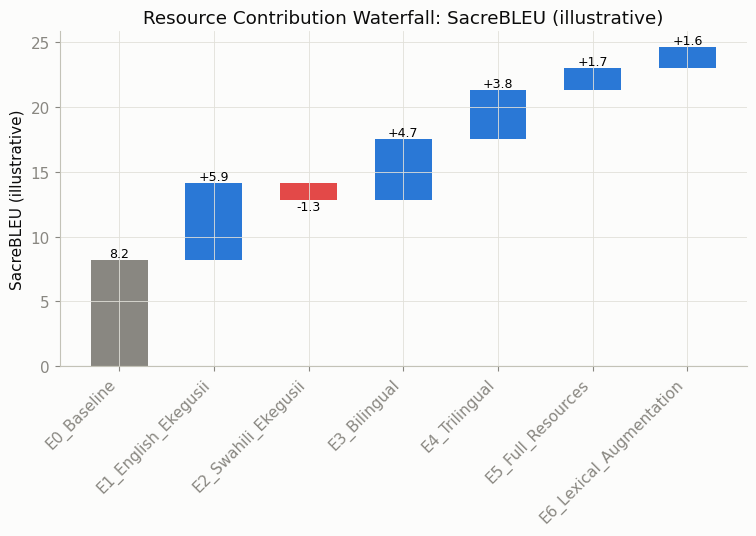

In [6]:
fig = plot_resource_waterfall(example_scores, metric_name='SacreBLEU (illustrative)',
    output_path='outputs/figures/11_waterfall.png')

## Significance testing (once per-sentence scores are available)

In [7]:
from src.evaluation.significance import PairedBootstrapTest

# Illustrative per-sentence scores -- replace with real per-sentence COMET/chrF
# arrays for two experiments on the SAME test-set sentence order.
import numpy as np
rng = np.random.default_rng(42)
scores_e1 = rng.normal(14.1, 5, 200).tolist()
scores_e4 = rng.normal(21.3, 5, 200).tolist()

test = PairedBootstrapTest(n_resamples=2000)
test.run(scores_e4, scores_e1, 'E4_Trilingual', 'E1_English_Ekegusii')

INFO | Bootstrap test [E4_Trilingual vs E1_English_Ekegusii]: diff=7.4526, p=0.0000, significant=True


{'system_a': 'E4_Trilingual',
 'system_b': 'E1_English_Ekegusii',
 'n_sentences': 200,
 'mean_a': 21.4004,
 'mean_b': 13.9477,
 'mean_diff': 7.4526,
 'p_value': 0.0,
 'significant_at_0.05': True}